# 自动驾驶目标检测

# 比较各种yolov8n检测器的检测效果

In [5]:
from ultralytics import YOLO
import os, random, cv2, matplotlib.pyplot as plt
import cv2
import numpy as np
import torch

np.random.seed(42)
torch.manual_seed(42)


yolo_path = r'D:\AIR\Teaching\models\yolov8n.pt'   # 原始yolov8n检测器  
#yolo_path = r'D:\AIR\Teaching\models\yolov8n-tsd-only.pt'  # tsd数据集训练的yolov8n检测器
#yolo_path = r'D:\AIR\Teaching\models\yolov8n-tsd-phase2.pt' # tsd+selfdrvingcar数据集训练的yolov8n检测器

model = YOLO(yolo_path)          # 轻量模型


# 选取一段视频，生成模型检测视频流，查看效果

In [6]:
# Video input and output paths
# input_video_path = r'D:\AIR\Teaching\Dataset\Privates\auto_test_4.mp4'
input_video_path = r'D:\AIR\Teaching\Dataset\TrafficSignsDetection\video.mp4'

output_video_path = r'D:\AIR\Teaching\Dataset\TrafficSignsDetection\video_yolo_orig.mp4'

#output_video_path = r'D:\AIR\Teaching\Dataset\Privates\auto_test_4_yolo_tsd_only.mp4'


cap   = cv2.VideoCapture(input_video_path)
out   = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'mp4v'), 30,
                        (int(cap.get(3)), int(cap.get(4))))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    results = model(frame)  
    annotated = results[0].plot()
    out.write(annotated)

cap.release(); out.release()


0: 640x640 1 stop sign, 37.0ms
Speed: 4.3ms preprocess, 37.0ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 stop sign, 39.9ms
Speed: 4.0ms preprocess, 39.9ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 stop sign, 40.9ms
Speed: 4.1ms preprocess, 40.9ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 38.3ms
Speed: 4.3ms preprocess, 38.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 stop sign, 39.1ms
Speed: 4.5ms preprocess, 39.1ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 stop sign, 38.4ms
Speed: 4.1ms preprocess, 38.4ms inference, 3.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 40.0ms
Speed: 4.2ms preprocess, 40.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 stop sign, 39.5ms
Speed: 4.4ms preprocess, 39.5ms inference, 3.6ms postproc

# 随机选取自动驾驶测试集中的6张图片，检测效果

In [2]:
SRC_DIR   = r"D:\AIR\Teaching\Dataset\SelfDrivingCar\images"
DST_VIDEO = r"D:\AIR\Teaching\Dataset\SelfDrivingCar\result.mp4"

In [3]:
img_files = sorted([f for f in os.listdir(SRC_DIR) 
                    if f.lower().endswith(('.jpg','.png','.jpeg'))])
img_paths = [os.path.join(SRC_DIR, f) for f in img_files]


In [4]:
def show_random_results(paths, show_num=6, rows=2, cols=3):
    """
    paths    : 所有图片路径列表
    show_num : 随机要展示的帧数（默认 6）
    rows/cols: 网格行列（默认 2×3）
    """
    show_num = min(show_num, len(paths))          # 防越界
    chosen_paths = random.sample(paths, show_num)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 9))
    for ax, p in zip(axes.ravel(), chosen_paths):
        res = model.predict(p, conf=0.25, verbose=False)[0]
        ax.imshow(res.plot()[:, :, ::-1])
        ax.set_title(os.path.basename(p), fontsize=8)
        ax.axis('off')
    # 剩余空白子图关闭
    for ax in axes.ravel()[show_num:]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [5]:
def infer_to_video(paths, dst_video, video_frames=100, fps=20):
    """
    paths        : 所有图片路径列表
    video_frames : 取前多少帧做视频（默认 100）
    fps          : 输出视频帧率
    """
    paths = paths[:video_frames]
    if not paths:
        raise ValueError("未找到任何图片")

    h, w = cv2.imread(paths[0]).shape[:2]
    vw = cv2.VideoWriter(dst_video,
                         cv2.VideoWriter_fourcc(*'mp4v'),
                         fps, (w, h))

    for p in paths:
        res = model.predict(p, conf=0.25, verbose=False)[0]
        vw.write(res.plot())

    vw.release()
    print(f"✅ 视频完成！已保存至: {dst_video}")

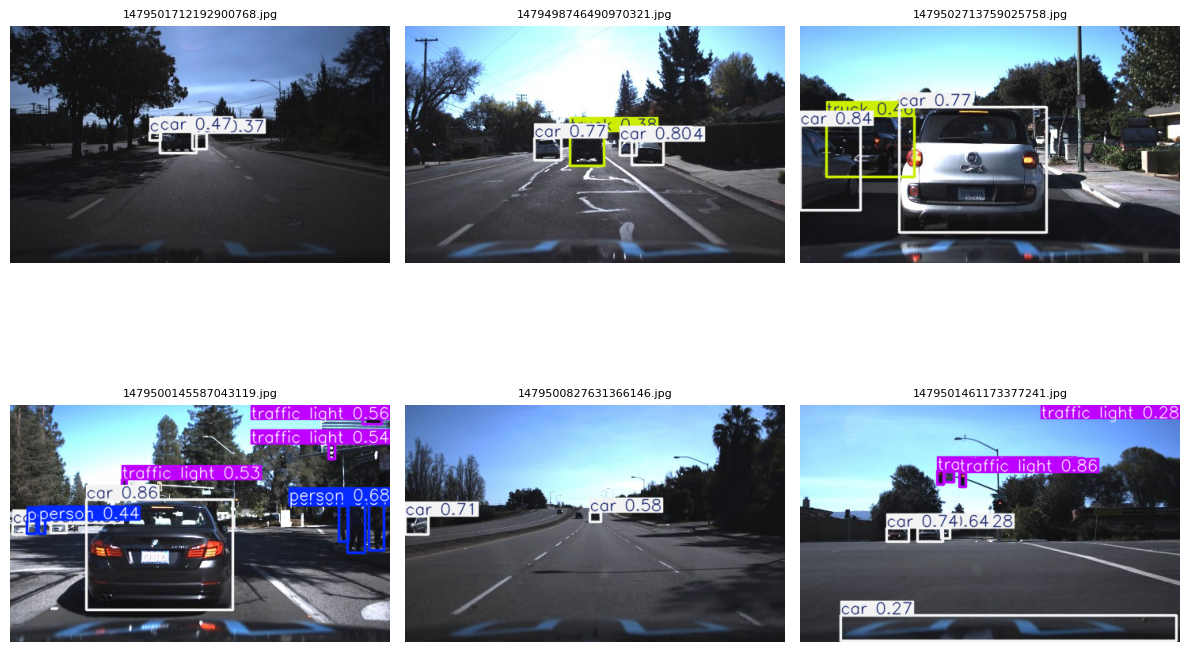

In [9]:
# 1. 随机展示 6 张，用 3×3 网格
show_random_results(img_paths, show_num=6, rows=2, cols=3)

In [10]:
# 2. 把前 500 帧做成 25 fps 视频
infer_to_video(img_paths, dst_video=DST_VIDEO, video_frames=500, fps=5)

✅ 视频完成！已保存至: D:\AIR\Teaching\Dataset\SelfDrivingCar\result.mp4
